# Calculation of the ground state energy of the 7Li atom
# All-electrons ECG basis functions - Julia

|||
|-|-|
|**Authors:** |Alain Chancé|
|**Lead investigator:** |Alain Chancé|
|**Date:** |June 4, 2023|
|**Version:** |**1.00**<br/>*Details see at the end of this notebook*|
|**References:**|
[Keeper L. Sharkey and Ludwik Adamowicz, An algorithm for nonrelativistic quantum-mechanical finite-nuclear-mass variational calculations of nitrogen atom in L = 0, M = 0 states using all-electrons explicitly correlated Gaussian basis functions, J. Chem. Phys. 140, 174112 (2014)](https://www.researchgate.net/profile/Keeper-Sharkey/publication/262192447_An_algorithm_for_nonrelativistic_quantum-mechanical_finite-nuclear-mass_variational_calculations_of_nitrogen_atom_in_L0_M0_states_using_all-electrons_explicitly_correlated_Gaussian_basis_functions/links/02e7e53cdb4298d92b000000/An-algorithm-for-nonrelativistic-quantum-mechanical-finite-nuclear-mass-variational-calculations-of-nitrogen-atom-in-L0-M0-states-using-all-electrons-explicitly-correlated-Gaussian-basis-functions.pdf)
[Nikita Kirnosov, ADVANCES IN MODELING OF PHYSICAL SYSTEMS USING EXPLICITLY CORRELATED GAUSSIAN FUNCTIONS, A Dissertation Submitted to the Faculty of the DEPARTMENT OF PHYSICS In Partial Fulfillment of the Requirements For the Degree of DOCTOR OF PHILOSOPHY In the Graduate College THE UNIVERSITY OF ARIZONA, 2015](https://repository.arizona.edu/bitstream/handle/10150/594645/azu_etd_14350_sip1_m.pdf?sequence=1&isAllowed=y)
[Sergiy Bubin and Ludwik Adamowicz, Computer program ATOM-MOL-nonBO for performing calculations of ground and excited states of atoms and molecules without assuming the Born–Oppenheimer approximation using all-particle complex explicitly correlated Gaussian functions. J. Chem. Phys. 152, 204102 (2020), 26 May 2020](https://doi.org/10.1063/1.5144268)
[Amir Bralin, Sergiy Bubin, Monika Stanke, Ludwik Adamowicz, The,  Rydberg series of the lithium atom. Calculations with all-electron explicitly correlated Gaussian functions, Chemical Physics Letters 730 (2019) 497–5](https://doi.org/10.1016/j.cplett.2019.06.051)
<br/>

# Description
This jupyter notebook performs a calculation of the ground state energy of the 7Li atom.It computes an energy of -7.47732 in Hartree atomic units with a basis of 12 ECGs with input data from the following paper:

[Bralin] The Rydberg series of the lithium atom. Calculations with all-electron explicitly correlated Gaussian functions, Chemical Physics Letters 730 (2019) 497–5, https://doi.org/10.1016/j.cplett.2019.06.051

For the $^2S$ states of the lithium atom the symmetry projector can be chosen as: $Y = (1+P12)(1-P23)$.

Table 1, 7Li, −7.477451930731(1). Infinite results are obtained using a simple polynomial-based extrapolation procedure

This Jupyter notebook performs the following tasks:
* Read inout text file that specifies number of particles, charges, masses and non-linear 
basis set parameters
* Include relevant variant of the ECG_Matelem module
* Compute Hamiltonian H and overlap S matrices with two real $L=0$ correlated Gaussians
* Solve secular equation $H c=E S c$ to find the energy

## Include file ECG_Param.jl which contains module ECG_Param

## Run the calculation

This example is driven by `ecg_config.json` and executed through the [`ECG_Julia`](../ECG_Julia) package. `run_ecg` reads the configuration, stages the data files listed in its `setup.copy`, selects the matrix-element model (`MatElem_method`), solves the secular equation, and closes the trace file.


Including ECWaveFunction.jl from the package MolStructSampling.jl downloaded from https://github.com/LucasLang/MolStructSampling.jl
apply! - ECG_Param.verbose = 1
apply! - ECG_Param.compute_H_S_method = "basis terms"
apply! - ECG_Param.MatElem_method = "CGL0"
apply! - ECG_Param.GSEPSolutionMethod = "G"
apply! - ECG_Param.do_GSEPIIS = false
apply! - ECG_Param.do_Fortran = false
apply! - ECG_Param.max_print_H = 2
apply! - ECG_Param.overlap_Skl = true
apply! - param0.name = "7Li atom"
apply! - param0.npart = 4
apply! - param0.cbs = 4
apply! - param0.NumYHYTerms = 4
apply! - param0.ntrials = 1
apply! - param0.ApproxEnergy = -7.47755
apply! - param0.TargetEnergy = -7.47755
apply! - param0.MaxEnergyEval = 17
apply! - param0.seed = 1
apply! - param0.nlp0 = true
apply! - param0.coeff_nlp = 1.1
apply! - param0.shuffle_NonlinParam = true
apply! - param0.condition_max = 1.0e10
apply! - param0.overlap_threshold = 0.98
apply! - param0.nlp_threshold = 50.0
apply! - param0.dist_diagH_threshold = 0.0

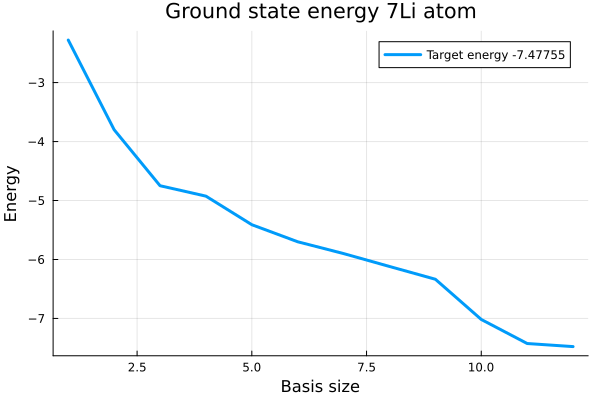


do_action - updated ecg_config.json with 12 action(s)

Writing inout file inout_1.txt

do_action - total wall-clock time: 10.81 s


In [1]:
# Load ECG_Julia and run this example.
# The package module is included directly (no Pkg.activate), so it works inside
# the Jupyter/IJulia kernel without switching environments. ECG_Julia's deps
# (Plots, Optim, ForwardDiff, JSON, Parameters, Distances) must be installed in
# the kernel's environment.
include("../ECG_Julia/src/ECG_Julia.jl")
using .ECG_Julia
ECG_Julia.run_ecg(".")


# Description of the modules

# Table of contents

**Modules**
* Module ECG_Param — parameters and the `param0` (Init_param) defaults
  * New fields in param0 (truncation, ramp, analytic gradient, trial-generation RG controls)
* Module ECG_Config — JSON-driven parameter reconstruction
* Module ECG_Init — initialisation, Young/symmetry operators, BFPI, set_parvec
  * Module SymmetryOperators
  * Basis Function Prefactor Indices (BFPI)
* Module ECG — H/S assembly, secular equation, optimisation, do_action
* Module ECG_Fortran — text-file interface to the external Fortran program (`main`)
* Modules ECG_Matelem_* — matrix elements and derivatives (Dk, Dl)
  * RGL0 — two real $L=0$ Gaussians
  * CGL0 — two complex $L=0$ Gaussians
  * Nitrogen (N_Pvec, N_matr, N_C_Pvec) — $L=0$
  * RGL1 — two real $L=1$ Gaussians

**Appendices**
* Appendix A — Hamiltonian, permutational symmetry
* Appendix B — Solving the secular equation; energy gradient and automatic differentiation
* Appendix C — The Vec and Vech operators
* Appendix D — Transposition matrices
* Appendix E — Ground-state energies for the N atom ($L=0$, $M=0$)
* Appendix F — Code flowchart
* References

## Module ECG_Param
Module ECG_Param defines the following parameters:
* compute_H_S_method
* MatElem_method
* Method used by StoreHS() function
* do_Fortran = true && isfile("main")
* inout_file = "inout.txt"
* param_file = "Param_Julia.txt"
* Mass_file = "Mass.txt"
* PseudoCharge_file = "PseudoCharge.txt"
* NonlinParam_file = "NonlinParam.txt"
* _EPS = 1e-15 # Global variable used to chop small numbers to zero
* YOperatorStringLength=100

### New fields in param0 (the Init_param structure)
The default-parameter structure `param0` carries, in addition to the original fields, the following controls added for symmetry-term truncation and analytic-gradient optimization:
* `coeff_threshold::Float64 = 0.0` — symmetry-term truncation threshold used to guide the nonlinear-parameter optimization (`optim_nlp`). During the inner BFGS search, $Y^{\dagger}Y$ terms whose $|\mathrm{YHYCoeff}| < \mathrm{coeff\_threshold}$ are skipped, giving a cheaper, partially symmetrized (non-variational) energy surface; every accepted/reported energy is recomputed with the full operator. `0.0` disables truncation (full operator everywhere). For Nitrogen the coefficients are $|c| \in \{96,192,960\}$, so `coeff_threshold = 192` drops the 96-class (~48% of the 5040 terms) and `960` keeps only the 240 dominant terms.
* `coeff_ramp_tol::Float64 = 0.0` — automatic threshold ramp. When $> 0$, `optim_nlp` starts at `coeff_threshold` (coarse) and lowers the threshold to the next-finer coefficient tier — eventually $0$ (full operator) — whenever a cycle's total energy improvement falls below `coeff_ramp_tol`. `0.0` keeps a fixed threshold (no ramp). Requires `coeff_threshold > 0`.
* `analytic_grad::Bool = false` — when `true`, `optim_nlp` passes an analytic energy gradient (`loss_grad!`) to Optim instead of relying on Optim's finite-difference gradient (see Appendix B). It requires a matrix-element module that returns correct `Dk`/`Dl`; the default N_Pvec matelem does, via automatic differentiation. `false` keeps the finite-difference path unchanged.

It also carries the following controls for the trial-function generation in `stoch_nlp`, ported from the Fortran reference code:
* `gen_NonlinParam::Bool = false` — selects how `stoch_nlp` produces each trial function inside its `for u in 1:MaxEnergyEval` loop. When `true`, the **first method tried** is `gen_trial_param!`, a Julia port of the Fortran subroutine `GenerateTrialParam`[ATOMMOLnonBO]: it perturbs a randomly selected existing (template) function by one of two stochastic methods (below). When `false` (default) the existing generation is used unchanged — a uniform draw blended with the template, `r·(coeff_nlp·uniform[-0.5,0.5) + template)` with `r` drawn from $[0.8,1.2]$. The two paths are otherwise identical (same overlap/condition/distance rejection, same `ZIndex` prefactor inheritance), so turning the flag off reproduces previous results bit-for-bit.
* `RG_p1::Float64 = 0.7` — probability of using generation **method 1** (independent per-parameter scaling); with probability $1-\mathrm{RG\_p1}$ **method 2** (a single common scaling factor for all parameters of the selected function) is used instead. [Fortran `Glob_RG_p1`]
* `RG_s1::Float64 = 1.0` — method-1 relative standard deviation: each new parameter is $\bigl(1 + \mathrm{RG\_s1}\cdot Z\bigr)\cdot\text{template}$ with $Z\sim N(0,1)$ drawn independently per parameter. [Fortran `Glob_RG_s1`]
* `RG_s2::Float64 = 3.0` — method-2 relative standard deviation: a single factor $\bigl(1 + \mathrm{RG\_s2}\cdot Z\bigr)$ multiplies all parameters of the selected function, redrawn until $|\text{factor}|$ lies outside $(0.8, 1.2)$ so the candidate is not almost linearly dependent on its template. [Fortran `Glob_RG_s2`]

The defaults `(0.7, 1.0, 3.0)` are the `GENERATOR_PARAM` values from the Fortran Li input (`inout_F90.txt`). They are deliberately aggressive (broad exploration); because they can drive a small basis toward near-linearly-dependent functions and spurious low eigenvalues, ensure `TargetEnergy` is set at or slightly below the exact energy (it is the physical lower bound and the collapse repeller) and/or reduce `RG_s1`/`RG_s2` if variational collapse is observed.

## Module ECG_Config — JSON-driven parameter reconstruction
Module ECG_Config reconstructs the run parameters from a single JSON configuration file (default `ecg_config.json`), replacing the manual post-`include` mutation of `ECG_Param` globals and `param0` fields. The JSON file fully describes a run and can be written by hand or generated by an external tool (e.g. a Python/Gradio interface).

### ecg_config.json structure
```
{
  "setup":     { "copy":  [ ...module and data files copied into the working directory... ],
                 "clean": [ ...stale work files removed before the run... ] },
  "ECG_Param": { ...module-level ECG_Param settings: compute_H_S_method, MatElem_method, do_Fortran, ... },
  "param0":    { ...fields of the ECG_Param.param0 (Init_param) instance: name, npart, cbs, seed,
                   coeff_threshold, coeff_ramp_tol, analytic_grad, ... },
  "actions":   [ ...optional command script: one object per action (Type, solver_type, nfa, nfo,
                   ntrials, MaxEnergyEval, Kstart, Kstop, Kstep, seed, nlp0, coeff_nlp)... ]
}
```

### Functions
* `read_config(path)` — parse the JSON configuration file.
* `setup_workdir!(cfg)` — copy the files listed in `setup.copy` into the working directory and remove the `setup.clean` files, using native Julia `Base.cp(src, dst; force=true)` (the equivalent of Python's `shutil.copy`) wrapped as `safe_cp()` — no shell commands. A copy entry is either a path (copied under its own name) or `{"from": path, "to": name}` to copy-with-rename (e.g. installing a Fortran binary as `main`).
* `apply!(cfg)` — overlay `cfg["ECG_Param"]` onto the module-level globals and `cfg["param0"]` onto the `param0` fields, converting each value to the declared field type; unknown keys produce a warning rather than failing silently.
* `save_config(path; include_actions=true)` — write the current `ECG_Param`/`param0` settings (and, when `include_actions`, the current `action_list`) to a JSON template (useful for generating a config for an external UI to edit).

### Typical notebook usage
```julia
include("../ECG_Julia/ECG_Config.jl")
cfg = ECG_Config.read_config("ecg_config.json")
ECG_Config.setup_workdir!(cfg)     # native-Julia file copies / cleanup (no shell)
include("ECG_Param.jl")            # parameter defaults
ECG_Config.apply!(cfg)             # overlay the JSON values
include("ECG_Init.jl")
include("ECG.jl")
ok = ECG.do_action()
```

### Actions (alternate to `inout.txt`)
The optional top-level `"actions"` array carries the command script in the configuration instead of the legacy `inout.txt`. Each entry mirrors the `ECG_Init` `action` struct, with `Type` the action **name** (`BASIS_ENL`, `OPT_CYCLE`, `FULL_OPT1`, `CHECK`, `BASIS_REPL`, `BASIS_ENL_F90`, `OPT_CYCLE_F90`) and `seed` an integer or `null`. `apply!` stores the array in `ECG_Param.config_actions`; `data_init()` then converts it (via `actions_from_config`) into the `action_list`, **replacing** the script parsed from `inout.txt` (the system and basis still come from `inout.txt`). When `"actions"` is absent, the legacy `inout.txt` script is used unchanged. The reverse converter `actions_to_config(action_list)` (used by `save_config`) serializes the current actions back to the JSON form. `read_config` remembers the path it read, and `do_action()` calls `ECG_Config.write_config_actions!` just before writing `inout_1.txt` — updating that configuration file's `"actions"` with the executed `action_list` (other sections untouched), so it is ready to drive a follow-on run.

## Module ECG_Init
Module ECG_Init performs the following tasks:
* Import a selection of variables from module ECG_Param
* Create or open a trace file
* Print parameters
* Define global variables
* Define constants
* Generate Basis function prefactor indices, BFPI

then it defines the following functions:
* setup_nlp() that sets up trial non-linear basis set parameters for a given number of basis functions
* Write_NonlinParam that writes non-linear basis set parameters into file NonlinParam_file
* Read_inout() that reads an inout.txt file using DelimitedFiles
* Read_Param() that reads matrix elements parameters from a file
* Reduced_Mass() that constructs the reduced mass matrix
* Read_matrix_3D() that reads a 3D matrix from a file
* Read_NonlinParam() that reads non-linear basis set parameters from a file
* set_Transposit() that constructs a 4D matrix of all pair permutations
* set_Young() that sets up Young operators, list and count their independent terms
* data_init() that initializes data structures (reading the $Y$/$Y^{\dagger}Y$ operator files when present, else computing them with module `SymmetryOperators`)

then it initializes data structures:
* Initialize data structures 
* Define structure Param that is used to pass parameters using Parameters https://github.com/mauro3/Parameters.jl
* Create an instance param of the Param structure

Finally it defines set_parvec() that creates parvec matrix

### set_Transposit() constructs a 4D matrix of all pair permutations
The $P_{1 i}(i \neq 1)$ transposition matrix has the following form, where indices start from 1 (Appendix A, Transposition matrices 𝑃𝑖𝑗):

$$\left\{\begin{array}{c}
P_{k, k}=1 \text { if } k \neq i-1 \\
P_{k, i-1}=-1 \\
P_{k, l}=0 \text { if } k \neq l \text { and } k \neq i-1
\end{array}\right.$$

The 4D array Transposit contains all pair permutation matrices (transpositions) and has the following structure: 
```
Transposit[0:n,0:n,1,2] corresponds to P12
Transposit[0:n,0:n,5,5] corresponds to P55
```

### data_init() initializes data structures
3D arrays YMatr and YHYMatr contain all matrices for $Y$ and $Y^{\dagger}Y$ operators. The structure is as follows:
* YHYMatr(1:n,1:n,5) is the matrix corresponding to the 5-th term of $Y^{\dagger}Y$ operator
* Arrays YCoeff and YHYCoeff contain all coefficients (coefficients of permutations) in the $Y$ and $Y^{\dagger}Y$ operators.
* Variables NumYTerms and NumYHYTerms are the number of independent terms in the $Y$ and $Y^{\dagger}Y$ operator respectively.

`data_init()` populates these arrays in one of two ways. When all four reference files `YCoeff.txt`, `YMatr.txt`, `YHYCoeff.txt`, `YHYMatr.txt` are present in the working folder, they are read directly (the ATOM-MOL-nonBO convention). When any of them is missing, the operators are instead **computed on the fly by module `SymmetryOperators`** (see below) from the Young-operator string and the number of pseudoparticles $n$, and a message is logged naming the missing file(s).

### Module SymmetryOperators
`symmetry_operators.jl` defines module `SymmetryOperators`, included by `ECG_Init.jl` (`import .SymmetryOperators`). Its entry point

```julia
sym = SymmetryOperators.compute_operators(YOperatorString, n)
```

parses the permutational Young-operator string (e.g. products of transpositions/cycles such as `P56`, `P78`, `P13P24`) and returns the symmetry-projection operator $\hat{Y}$ and the projector $\hat{P}=\hat{Y}^{\dagger}\hat{Y}$ as lists of permutation matrices with integer coefficients — the fields `YCoeff`, `YMatr`, `YHYCoeff`, `YHYMatr`, `NumYTerms`, `NumYHYTerms` that `data_init()` copies into `param`. It builds the **full** $\hat{Y}^{\dagger}\hat{Y}$ (every product term with its coefficient), so the resulting operator can differ from a hand-reduced reference file that stored a contracted form (e.g. the Beryllium 16-term vs. 24-term distinction). The computed operators were verified against the ATOM-MOL-nonBO reference files for the HD$^+$, D$_3^+$ and Nitrogen-atom cases. This fallback is what lets a working folder run with **no** `Y*`/`YHY*` text files at all, and it is the source of the $\mathrm{YHYCoeff}$ used by the symmetry-term truncation and the analytic-gradient assembly described above.

### Basis Function Prefactor Indices (BFPI)
For the $L=0$, $M=0$ states of the atoms from Lithium ($n=3$ pseudoparticles) to Nitrogen ($n=7$), each ECG basis function carries an **angular prefactor** multiplying the correlated Gaussian, built from the (z-component) coordinates of **three distinct pseudoparticles**. `BFPI` (generated in `ECG_Init.jl`) is a $36\times3$ integer table cataloguing those index triples: row $r$ holds a triple $(i,j,k)$ of three distinct pseudoparticle indices, and a basis function's `ZIndex` selects which row — i.e. which prefactor — it uses.

The table enumerates every triple of distinct indices drawn from $\{1,\dots,7\}$ ($\binom{7}{3}=35$ triples; row 36 is spare), grouped by the **largest** index in the triple (the pseudoparticle at which that index first becomes available):

$$\begin{array}{|c|c|c|c|}
\hline
\textbf{largest index} & \textbf{rows} & \textbf{atom} & \textbf{triples}\\
\hline
3 & 1 & \text{Lithium } (n=3) & 1 = \binom{2}{2}\\
4 & 2\text{--}4 & \text{Beryllium } (n=4) & 3 = \binom{3}{2}\\
5 & 5\text{--}10 & \text{Boron } (n=5) & 6 = \binom{4}{2}\\
6 & 11\text{--}20 & \text{Carbon } (n=6) & 10 = \binom{5}{2}\\
7 & 21\text{--}35 & \text{Nitrogen } (n=7) & 15 = \binom{6}{2}\\
\hline
\end{array}$$

The blocks are **cumulative**: an atom with $n$ pseudoparticles may use every row whose three indices are $\le n$, i.e. rows $1$ through the end of its block (Lithium row 1 only, …, Nitrogen all 35 rows). In particular a valid Nitrogen `ZIndex` is any of $1\dots35$ — not only the $21$–$35$ block, which is merely the subset of triples that happen to contain index $7$. (Note: an incorrect default `ZIndex = 1` silently selects the Lithium prefactor; see the `stoch_nlp` `ZIndex_t_defined` guard.)

Reference: Sharkey & Adamowicz, *"An algorithm for nonrelativistic quantum-mechanical finite-nuclear-mass variational calculations of nitrogen atom in $L=0$, $M=0$ states using all-electrons explicitly correlated Gaussian basis functions"*, J. Chem. Phys. **140**, 174112 (2014), https://doi.org/10.1063/1.4873916.

### set_parvec()
`set_parvec()` looks up the bra and ket prefactor triples via `BFPI[ZIndex[k0],:]` and `BFPI[ZIndex[l0],:]`, permutes the ket triple through the permutation column `PP[:,j0]`, and assembles the $36$-row `parvec` matrix (paired with the sign vector `covec`) that `ECG_Matelem_N_Pvec` / `ECG_Matelem_N_C_Pvec` sum to evaluate the prefactor-weighted overlap, kinetic and potential matrix elements.

### Julia Parameters package
Best practice for storing, passing, and managing parameters in economic models, 
https://discourse.julialang.org/t/best-practice-for-storing-passing-and-managing-parameters-in-economic-models/64705/3

## Module ECG
This module includes all matrix-element submodules (`ECG_Matelem_<method>`) and routes `MatrixElements` to the active one (`select_matelem!` / `_ACTIVE_MATELEM`). It defines the following functions:
* StoreHS() that stores and normalizes H and S matrix elements
* NormHS() that normalizes H and S matrices
* compute_H_S() that fills Hamiltonian H and overlap S matrices
* GSEPIIS() that solves secular equation $H c=E S c$ to find the energy
* solve_sec() that solves equation $H c=E S c$ to find the energy
* stoch_nlp() that randomly selects functions
* do_basis_enl() that enlarges the basis set
* do_opt_cycle() that performs an optimization cycle
* do_action() that processes actions

The Fortran-interface functions (`run_Fortran`, `compute_and_solve_F90`, `solve_F90`, `read_complex_matrix`) were moved out of this module into **module ECG_Fortran** (see the next section). ECG includes ECG_Fortran and imports those functions.

### GSEPIIS() solves secular equation $H c=E S c$ to find the energy
We use Julia Linear Algebra bunchkaufman function to compute the Bunch-Kaufman factorization of a symmetric matrix to solve secular equation $H c=E S c$, https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.bunchkaufman

The solution of the system $Ax=b$ where $A=L*D*L^{T}$ is found as a result of consecutive solutions of
systems $L*y=b$ and $D*L^{T}*x=y$.

### solve_sec() solves equation $H c=E S c$ to find the energy
solve_sec() uses the following methods to solve secular equation $H c=E S c$ to find the energy:
* GSEPIIS() function which finds the solution of the system $Ax=b$ where $A=L*D*L^{T}$ as a result of consecutive solutions of
systems $L*y=b$ and $D*L^{T}*x=y$. The Julia \ operation solves the linear solution.
* Julia linear algebra eigen() function which solves a standard or generalized eigenvalue problem for a complex Hermitian or real symmetric matrix: https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.GeneralizedEigen.

## Module ECG_Fortran
Module ECG_Fortran (`ECG_Fortran.jl`) groups the functions that drive and read back the external Fortran program (the `main` binary); they were split out of module ECG so that ECG itself stays free of the Fortran plumbing. The interface is **text-file based** — parameters and matrices are exchanged through `*.txt` files and `main` is launched as a subprocess (there is no in-memory API). These functions run only when `do_Fortran` is true.

ECG includes this module with `include("ECG_Fortran.jl")` and imports its public functions. The Fortran functions in turn need a few numerical helpers that live in module ECG (`read_matrix`, `write_matrix`, `symm`, `solve_eigen`, `compute_and_solve`); since ECG also imports the Fortran functions, the otherwise-circular module dependency is broken by **injection** — right after the include, ECG calls `ECG_Fortran.set_ecg_module!(ECG)`, giving ECG_Fortran a reference back to ECG through which those helpers are resolved at call time.

### Public functions
* `run_Fortran()` — the entry point. It writes the Fortran parameters, copies `NonlinParam.txt` → `Glob_NonlinParam.txt` and makes `main` executable (native Julia `cp`/`chmod`, no shell), runs `./main` with stdout redirected to `outfile`, then dispatches: if the program produced an `inout_F90`/`NonlinParam_F90` file it finishes through `compute_and_solve_F90`, otherwise (real methods) through `solve_F90`.
* `compute_and_solve_F90()` — read the nonlinear parameters returned by the Fortran program, recompute H and S and re-solve the secular equation, accepting the result only if its energy is a valid improvement; otherwise the previous `param` state is restored.
* `solve_F90()` — read the `H_90` / `S_90` matrix files produced by the Fortran program and re-solve the secular equation, again accepting only a valid improvement.
* `read_complex_matrix()` — read a matrix written by the Fortran program as interleaved (REAL, AIMAG) column pairs and reassemble it into a complex matrix, $U_{ij} = M_{i,\,2j-1} + i\,M_{i,\,2j}$.

### Internal helpers
* `_snapshot(param)` / `_restore!(param, snap)` capture and roll back the `param` fields that a Fortran round-trip may overwrite, so a rejected result leaves `param` unchanged.
* `_accept_energy(...)` is the shared accept/reject decision (energy below target, above the previous energy, NaN, or a valid improvement). Its comparison-phrase wording is passed per call so that `compute_and_solve_F90` and `solve_F90` keep their original log messages.

The numerical helpers (`compute_and_solve`, `solve_sec`, `solve_eigen`, `read_matrix`, `write_matrix`, `symm`) are described under module ECG; the secular-equation solution itself is covered in Appendix B.

## Modules ECG_Matelem_*
Each matrix-element variant lives in its own file `ECG_Matelem_<method>.jl` defining a uniquely-named submodule — `ECG_Matelem_RGL0`, `ECG_Matelem_CGL0`, `ECG_Matelem_RGL1`, `ECG_Matelem_N_Pvec`, `ECG_Matelem_N_matr`, `ECG_Matelem_N_C_Pvec` — each exposing a `MatrixElements()` that computes the H and S elements and (where available) their derivatives for its use case. Module `ECG` includes all of them and selects the active one at run time from `MatElem_method` via `select_matelem!()` (which sets `_ACTIVE_MATELEM[]`); a forwarding `MatrixElements(args...; kwargs...) = _ACTIVE_MATELEM[].MatrixElements(args...; kwargs...)` routes every call to the selected submodule.
### Input
```
   k0, l0         :  index in current basis set
   j0             :  index in symmetry terms
   grad_k, grad_l :  Gradient flags
   grad_k = true  :  Means that dHkl/dvechLk, dSkl/dvechLk need to be computed. 
   grad_l = true  :  Means that dHkl/dvechLl, dSkl/dvechLl need to be computed.
```
### Output:
```
   Hkl	 : Hamiltonian term (normalized)
   Skl	 : Overlap matrix element (normalized) 
   Dk,Dl : Derivatives of normalized Hkl and Skl with respect to vechLk and vechLl respectively. 
           They are ordered in the following manner:
           Dk=(dHkl/dvechLk,dSkl/dvechLk)
           Dl=(dHkl/dvechLl,dSkl/dvechLl)
```

### Computation of the derivatives Dk, Dl
The default N_Pvec matrix-element module (`ECG_Matelem_N_Pvec.jl`) computes `Dk` and `Dl` by **forward-mode automatic differentiation** (ForwardDiff.jl) of a single type-generic kernel that returns `(Hkl, Skl)` — every intermediate array is allocated with the *promoted* element type of the inputs so that ForwardDiff dual numbers propagate through the build, the pseudo-Cholesky/inverse and the 36-term `parvec`/`covec` sum. `Dk = (dHkl/dvechLk, dSkl/dvechLk)` is then a single `ForwardDiff.jacobian` of `[Hkl, Skl]` with respect to `vechLk` (and `Dl` with respect to `vechLl`). This replaces the previous hand-coded analytic derivative (`Grad_p`/`Grad_k`/`Grad_l`), which is preserved as `ECG_Matelem_N_Pvec_old.jl`. The AD derivatives were verified against central finite differences to relative ~$10^{-10}$. See Appendix B for how these element derivatives are assembled into the energy gradient.

### Definitions
$$\begin{array}{|c|c|c|}
\hline
\mathbf{Formula} &\mathbf{Definition} &\mathbf{Julia} \text{ } \mathbf{code}\\
\hline
\hat{P}=\hat{Y}^{\dagger} \hat{Y} & P \otimes I_3 \text{ operator} &\mathrm{YHYMatr}\\
\hline
 &j0^{th} \text{ term of the } Y^{\dagger}Y \text{ operator} &\mathrm{P = YHYMatr[...,j0]}\\
\hline
\text { vech } \mathrm{L}_k &\text{Vector half } \mathrm{L}_k & \mathrm { vechLk = NonlinParam[k,...]}\\
\hline
\text { vech } \mathrm{L}_l &\text{Vector half } \mathrm{L}_l &\mathrm { vechLl = NonlinParam[l,...]}\\
\hline
\mathrm{L}_k &\text{Lower triangular matrix } \mathrm{L}_k &\mathrm{Lk = vech2L(vechLk)}\\
\hline
\mathrm{L}_l &\text{Lower triangular matrix } \mathrm{L}_l &\mathrm{Ll = vech2L(vechLl)}\\
\hline
\mathrm{A}_k=\mathrm{L}_k \mathrm{L}_k^{\prime} &\text{Cholesky factored form} &\mathrm{Ak = Lk*transpose(Lk)}\\
\hline
\mathrm{A}_l=\mathrm{L}_l \mathrm{L}_l^{\prime} &\text{Cholesky factored form} &\mathrm{Al = Ll*transpose(Ll)}\\
\hline
\mathrm{A}_l^{\prime} = \mathrm{P}^{\prime}*\mathrm{A}_l*\mathrm{P} &\text{Backwards permutation on matrix } \mathrm{A}_l &\mathrm{tAl = transpose(P)*Al*P}\\
\hline
\mathrm{A}_{kl}^{\prime} = \mathrm{A}_k + \mathrm{A}_l^{\prime} &\text{ } &\mathrm{tAkl = Ak + tAl}\\
\hline
\mathrm{det\_tAkl} & \text{Determinant of matrix } \mathrm{tAkl} &\mathrm{det(tAkl)}\\
\hline
\mathrm{tAkl}^{-1} & \text{Inverse of matrix } \mathrm{tAkl} &\mathrm{inv(tAkl)}\\
\hline
\mathrm{AAk} & \mathrm{tAkl^{-1}*Ak} &\mathrm{AAk = inv\_tAkl * Ak}\\
\hline
\mathrm{AAl} & \mathrm{tAkl^{-1}*tAl} &\mathrm{AAl = inv\_tAkl * tAl}\\
\hline
\mathrm{H}_{k l}=\left\langle\phi_k\left|\hat{H} \hat{Y}^{\dagger} \hat{Y}\right| \phi_l\right\rangle &\text{Element of the Hamiltonian matrix H} &\mathrm{Hkl = Tkl+Vkl}\\
\hline
\mathrm{S}_{k l}=\left\langle\phi_k\left|\hat{Y}^{\dagger} \hat{Y}\right| \phi_l\right\rangle &\text{Element of the overlap matrix S} &\mathrm{tempSkl = A[xk,xl]*A[yk,yl]*A[zk,zl]} \text{ where } \mathrm{A = inv(tAkl)}\\
\hline
\end{array}$$

## Module ECG_Matelem_RGL0 with two real $L=0$ correlated Gaussians
### Description
This function computes symmetry adapted matrix element with two real correlated Gaussians for states with the rotation quantum number $L=0$ (all particles in s-state):

$$\phi_k(\mathbf{r})=\exp \left[-\mathbf{r}^{\prime} \overline{\mathbf{A}}_k \mathbf{r}\right]$$

$k$ ranges from 1 to $\mathbf{cbs}$ where $\mathbf{cbs}$ is the current number of basis functions. The prime symbol (') represents a vector or matrix transposition.

$\overline{\mathbf{A}}_k$ is a $3n$ X $3n$ real symmetric matrix of exponential parameters and can be written as $\overline{\mathbf{A}}_k=A_k \otimes I_3$, where $I_3$ is the $3$ X $3$ unit matrix, $\otimes$ denotes the Kronecker product, and $A_k$ is a $n$ X $n$ symmetric matrix. To ensure positive definiteness of the quadratic form, $A_k$ is represented in the Cholesky factored form as $A_k=L_k L_k^{\prime}$ where $L_k$ is an $n$ X $n$ rank $n$ lower triangular matrix. Hence:
$$\phi_k(r)=\exp \left[-r^{\prime} ( L_k L_k^{\prime} \otimes I_3) r\right]$$

Here $r$ is a $3n$ X $1$ vector of Cartesian coordinates for the $n$ particles. of Lk`

## Module ECG_Matelem_CGL0 with two complex $L=0$ correlated Gaussians
### Description
This function computes symmetry adapted matrix element with two complex correlated Gaussians for states with the rotation quantum number $L=0$ (all particles in s-state) [Bubin] (10):

$$\phi_k(\mathbf{r})=\exp \left[-\mathbf{r}^{\prime} \overline{\mathbf{C}}_k \mathbf{r}\right]=\exp \left[-\mathbf{r}^{\prime}\left(\overline{\mathbf{A}}_k+\mathrm{i} \overline{\mathbf{B}}_k\right) \mathbf{r}\right]=
\exp \left[-\mathbf{r}^{\prime} \overline{\mathbf{C}}_k \mathbf{r}\right]$$

$k$ ranges from 1 to $\mathbf{cbs}$ where $\mathbf{cbs}$ is the current number of basis functions. The prime symbol (') represents a vector or matrix transposition.

$\overline{\mathbf{A}}_k$ and $\overline{\mathbf{B}}_k$ are $3n$ X $3n$ real symmetric matrices of exponential parameters and can be written as $\overline{\mathbf{A}}_k=A_k \otimes I_3$, and $\overline{\mathbf{B}}_k=B_k \otimes I_3$ where $I_3$ is the $3$ X $3$ unit matrix, $\otimes$ denotes the Kronecker product, and $A_k$ is a $n$ X $n$ symmetric matrix. To ensure positive definiteness of the quadratic form, $A_k$ is represented in the Cholesky factored form as $A_k=L_k L_k^{\prime}$ where $L_k$ is an $n$ X $n$ rank $n$ lower triangular matrix. Hence:
$$\phi_k(r)=\exp \left[-r^{\prime}\left(L k^* L k^{\prime}+i B k\right) r\right]$$

## Modules ECG_Matelem_N_Pvec / ECG_Matelem_N_matr / ECG_Matelem_N_C_Pvec for Nitrogen with the rotation quantum number $L=0$
Modules N_Pvec and N_matr work with two real correlated Gaussians. Module N_C_Pvec works with two complex correlated Gaussians.

### The basis functions for Nitrogen
The full form of the basis function is given in ref. [KS_Nitrogen] III. THE BASIS FUNCTIONS equation (7):

$$\begin{aligned}
\psi_f= & \left\{\left(x_{j_f} y_{i_f}-x_{i_f} y_{j_f}\right) z_{k_f}+\left(x_{i_f} y_{k_f}-x_{k_f} y_{i_f}\right) z_{j_f}\right. \\
& \left.+\left(x_{k_f} y_{j_f}-x_{j_f} y_{k_f}\right) z_{i_f}\right\} \exp \left[-\mathbf{r}^{\prime} \mathbf{A}_f \mathbf{r}\right] \\
= & \left\{\left(\mathbf{r}^{\prime} \mathbf{v}_f^{x_j}\right)\left(\mathbf{r}^{\prime} \mathbf{v}_f^{y_i}\right)\left(\mathbf{r}^{\prime} \mathbf{v}_f^{z_k}\right)-\left(\mathbf{r}^{\prime} \mathbf{v}_f^{x_i}\right)\left(\mathbf{r}^{\prime} \mathbf{v}_f^{y_j}\right)\left(\mathbf{r}^{\prime} \mathbf{v}_f^{z_k}\right)\right. \\
& +\left(\mathbf{r}^{\prime} \mathbf{v}_f^{x_i}\right)\left(\mathbf{r}^{\prime} \mathbf{v}_f^{y_k}\right)\left(\mathbf{r}_f^{\prime} \mathbf{v}_f^{z_j}\right)-\left(\mathbf{v}_f^{\prime} \mathbf{x}_f\right)\left(\mathbf{r}_f^{\prime} \mathbf{v}_f^{y_i}\right)\left(\mathbf{r}^{\prime} \mathbf{v}_f^{z_j}\right) \\
& \left.+\left(\mathbf{r}^{\prime} \mathbf{v}_f^{x_k}\right)\left(\mathbf{r}^{\prime} \mathbf{v}_f^{y_j}\right)\left(\mathbf{r}^{\prime} \mathbf{v}_f^{z_i}\right)-\left(\mathbf{r}^{\prime} \mathbf{v}_f^{x_j}\right)\left(\mathbf{r}^{\prime} \mathbf{v}_f^{y_k}\right)\left(\mathbf{r}^{\prime} \mathbf{v}_f^{z_i}\right)\right\} \\
& \times \exp \left[-\mathbf{r}^{\prime} \mathbf{A}_f \mathbf{r}\right] .
\end{aligned}$$

As this basis function has six unique terms, there is a total of 36 elemental integrals when solving for each Hamiltonian or overlap matrix element.

### Permutational symmetry
The permutational symmetry is implemented in the basis functions by projecting each basis function using a symmetry-projection operator Y:

$$\psi_k=Y \Phi_k=\sum_P \chi_p r_1^{m_k} \exp \left[-\boldsymbol{r}^{\prime}\left(\tau_p^{\prime} L_k L_k^{\prime} \tau_p \otimes I_3\right) \boldsymbol{r}\right]$$

where the sum runs over all permutations of the labels of identical particles and where $\tau_p$ are permutational matrices transforming the internal coordinates.

The elements of the Hamiltonian and overlap matrices, 
$\mathrm{H}_{k l}=\left\langle\phi_k\left|\hat{H} \hat{Y}^{\dagger} \hat{Y}\right| \phi_l\right\rangle$
and $\mathrm{S}_{k l}=\left\langle\phi_k\left|\hat{Y}^{\dagger} \hat{Y}\right| \phi_l\right\rangle$, 
are calculated in the chosen set of explicitly correlated basis functions, $\left\{\phi_k\right\}$.

### Overlap matrix elements
The formula for the overlap matrix elements is given in ref. [KS_Nitrogen] B. Overlap matrix elements (29):

$$\left\langle\phi_f \mid \phi_g\right\rangle=\frac{1}{8} \pi^{3 n / 2}\left|A_{f g}\right|^{-3 / 2} \eta_x \eta_y \eta_z$$

$$=\frac{1}{8} \pi^{3 n / 2}\left|A_{f g}\right|^{-3 / 2}\left(A_{f g}^{-1}\right)_{\left(x_f, P \operatorname{vec}\left(x_g\right)\right)}
\times\left(A_{f g}^{-1}\right)_{\left(y_f, P \operatorname{vec}\left(y_g\right)\right)}\left(A_{f g}^{-1}\right)_{\left(z_f, P \operatorname{vec}\left(z_g\right)\right)}$$

### Potential energy matrix elements
The formula for the potential energy matrix elements is given in ref. [KS_Nitrogen] C. Potential energy matrix elements (44):
$$\begin{aligned}
\left\langle\phi_f\left|\frac{1}{r_{i^{\prime} j^{\prime}}}\right| \phi_g\right\rangle= & \frac{1}{4} \pi^{(3 n-1) / 2}\left|A_{f g}^{-1}\right|^{-3 / 2} \lambda^{-1 / 2}\left\{\eta_x \eta_y \eta_z\right. \\
& -\frac{\lambda^{-1}}{3}\left(\eta_x \eta_y \eta_{z J}+\eta_x \eta_{y J} \eta_z+\eta_{x J} \eta_y \eta_z\right) \\
& +\frac{\lambda^{-2}}{5}\left(\eta_x \eta_{y J} \eta_{z J}+\eta_{x J} \eta_y \eta_{z J}+\eta_{x J} \eta_{y J} \eta_z\right) \\
& \left.-\frac{\lambda^{-3}}{7} \eta_{x J} \eta_{y J} \eta_{z J}\right\}
\end{aligned}$$

where $\left|A_{f g}^{-1}\right|$ represents the determinant of matrix $A_{f g}^{-1}$.

### Kinetic energy matrix elements
The final formula for the kinetic energy integral is given in [KS_Nitrogen] D. Kinetic energy matrix elements (65):
$$\begin{aligned}
\left\langle\nabla_{\mathbf{r}} \phi_f|\mathbf{M}| \nabla_{\mathbf{r}} \phi_g\right\rangle= & \frac{1}{4} \pi^{3 n / 2}\left|A_{f g}\right|^{-3 / 2}\left\{3 \tau \eta_x \eta_y \eta_z\right. \\
& +\left(M_{\left(x_f, P \operatorname{vec}\left(x_g\right)\right)}+2 \tau_x-\left(A_{f g}^{-1} A_f M\right)_{\left(x_f, P \operatorname{vec}\left(x_g\right)\right)}-\left(M A_g A_{f g}^{-1}\right)_{\left(x_f, P \operatorname{vec}\left(x_g\right)\right)}\right) \eta_y \eta_z \\
& +\left(M_{\left(y_f, P \operatorname{vec}\left(y_g\right)\right)}+2 \tau_y-\left(A_{f g}^{-1} A_f M\right)_{\left(y_f, P \operatorname{vec}\left(y_g\right)\right)}-\left(M A_g A_{f g}^{-1}\right)_{\left(y_f, P \operatorname{vec}\left(y_g\right)\right)}\right) \eta_x \eta_z \\
& \left.+\left(M_{\left(z_f, P \operatorname{vec}\left(z_g\right)\right)}+2 \tau_z-\left(A_{f g}^{-1} A_f M\right)_{\left(z_f, P \operatorname{vec}\left(z_g\right)\right)}-\left(M A_g A_{f g}^{-1}\right)_{\left(z_f, P \operatorname{vec}\left(z_g\right)\right)}\right) \eta_x \eta_y\right\}
\end{aligned}$$

Three modules implement these elements: N_Pvec and N_matr (real Gaussians) and N_C_Pvec (complex). With the $36$ elemental
integrals carried by each of the $n!=5040$ permutation terms, evaluating a single nitrogen Hamiltonian or overlap matrix element requires the elemental-integral formula to be applied $180{,}240$ times [Sharkey2014] , so minimizing the work per permutation is essential. Following the permutational-symmetry scheme of Sharkey and Adamowicz [Sharkey2014] (Sec. IV), the $Pvec$ variants
avoid forming permutation-matrix products altogether: the forwards-direction permutation $(P_g v = v'P_g')$ is stored in the first half and the backwards-direction permutation $(P_g'v = vP_g')$ in the second half of a $2n$-component index vector $\mathrm{pvec}$ (Appendix C), so a permuted width-matrix element is obtained by an index gather,
$$
\begin{equation}
(P_g A P_g')_{(s,t)}=A_{(\mathrm{pvec}(s),\,\mathrm{pvec}(t))},\qquad
(P_g' A P_g)_{(s,t)}=A_{(\mathrm{pvec}(s+n),\,\mathrm{pvec}(t+n))},
\end{equation}
$$
rather than by multiplying matrices --- ``as long as we know the order of the particles, we know the order of the permuted matrix''~\cite{Sharkey2014}. This reduces forming $P_g'A_gP_g$ from $2n^3$ to $n^2$ operations (for nitrogen,
$686\to49$) and permuting a $3n$-vector from $(3n)^2$ to $n$ ($441\to7$) --- the principal per-permutation saving that $ECG\_Julia$ inherits.

### Computations for Nitrogen matelem modules N_Pvec and N_matr with two real correlated Gaussians
The vec() is an inbuilt function in julia which is used to reshape the specified array as a one-dimensional column vector i.e, 1D array. https://www.geeksforgeeks.org/reshaping-array-as-a-vector-in-julia-array-vec-method/
```
Lk = vec(NonlinParam[k,...], n)
Ll = vec(NonlinParam[l,...], n)

Ak = Lk*transpose(Lk)
Al = Ll*transpose(Ll)

P = YHYMatr[...,j0]

tAl = transpose(P)*Al*P
tAkl = Ak + tAl

det_tAkl = det(tAkl)
Z1 = cholesky(tAkl)

inv_tAkl = inv(tAkl)

AAk = inv_tAkl * Ak
AAl = inv_tAkl * tAl
MAk = MassMatrix * Ak
MAl = MassMatrix * tAl

AAkMAl = AAk * MAl
AAlMAk = AAl * MAk
AAkM = AAk * MassMatrix
AAlM = AAl * MassMatrix

AMA = AAkMAl * inv_tAkl
ATA = AAlMAk * inv_tAkl
MAkA = MAk * inv_tAkl
MAlA = MAl * inv_tAkl
```

### Computations for Nitrogen matelem module N_C_Pvec with two complex correlated Gaussians
Note that Ck actually contains Ck*.

```
Lk = vec(NonlinParam[k,...], n)
Ll = vec(NonlinParam[l,...], n)

Ak = Lk*transpose(Lk)
Al = Ll*transpose(Ll)

P = YHYMatr[...,j0]

tAl = transpose(P)*Al*P
tBl = transpose(P)*Bl*P

Ck = Ak - i*Bk

tCkl = tCl + Ck

det_tCkl = det(tCkl)
Z1 = cholesky(tCkl)

inv_tCkl = inv(tCkl)

AAk = inv_tCkl * Ak
AAl = inv_tCkl * tAl
MAk = MassMatrix * Ak
MAl = MassMatrix * tAl

AAkMAl = AAk * MAl
AAlMAk = AAl * MAk
AAkM = AAk * MassMatrix
AAlM = AAl * MassMatrix

AMA = AAkMAl * inv_tCkl
ATA = AAlMAk * inv_tCkl
MAkA = MAk * inv_tCkl
MAlA = MAl * inv_tCkl
```

## Module ECG_Matelem_RGL1 with two real $L=1$ correlated Gaussians
### Description
This function computes symmetry adapted matrix element with two real correlated Gaussians for states with the rotation quantum number $L=1$ (one particle in a p-state, others in s-state):

$$\phi_k(\mathbf{r})=z_{m_k}\exp \left[-\mathbf{r}^{\prime} \overline{\mathbf{A}}_k \mathbf{r}\right]$$

where:
* $k$ ranges from 1 to $\mathbf{cbs}$ where $\mathbf{cbs}$ is the current number of basis functions. The prime symbol (') represents a vector or matrix transposition.
* ${m_k}$ is an integer that depends on $k$.

$\overline{\mathbf{A}}_k$ is a $3n$ X $3n$ real symmetric matrix of exponential parameters and can be written as $\overline{\mathbf{A}}_k=A_k \otimes I_3$, where $I_3$ is the $3$ X $3$ unit matrix, $\otimes$ denotes the Kronecker product, and $A_k$ is a $n$ X $n$ symmetric matrix. To ensure positive definiteness of the quadratic form, $A_k$ is represented in the Cholesky factored form as $A_k=L_k L_k^{\prime}$ where $L_k$ is an $n$ X $n$ rank $n$ lower triangular matrix. Hence:
$$\phi_k(r)=z_{m_k}\exp \left[-r^{\prime} ( L_k L_k^{\prime} \otimes I_3) r\right]$$

Here $r$ is a $3n$ X $1$ vector of Cartesian coordinates for the $n$ particles. of Lk`

# Appendix A - Hamiltonian, permutational symmetry
Ref. [KS_Nitrogen] Keeper L. Sharkey and Ludwik Adamowicz, An algorithm for nonrelativistic quantum-mechanical finite-nuclear-mass variational calculations of nitrogen atom in L = 0, M = 0 states using all-electrons explicitly correlated Gaussian basis functions, J. Chem. Phys. 140, 174112 (2014).
## The Hamiltonian
The basis functions $\psi_f(\mathbf{r})$ for an $n$-electron atomic system with only $s$ electrons has only a radial exponential part and it is spherically symmetric (or rotationally invariant). In our calculations, $\psi_f(\mathbf{r})$ has the form of an ECG function:

$$\psi_f=\exp \left[-\mathbf{r}^{\prime}\left(A_f \otimes I_3\right) \mathbf{r}\right]$$

where $A_f$ is an $n \times n$ symmetric matrix, $\otimes$ is the Kronecker product symbol, and $I_3$ is a $3 \times 3$ identity matrix. In ECGs, all one-pseudoelectron exponential variables and all two-pseudoelectron coupling exponential variables
are included by the use of a quadratic form involving a vector-matrix-vector product, $\mathbf{r}^{\prime}\left(A_f \otimes I_3\right) \mathbf{r}$ (this form is used frequently in this work as it allows for some ease in the evaluation of the Hamiltonian and overlap matrix elements).

The angular part of the basis function for a state of three $p$ electrons with $L = 0$ and $M = 0$ becomes:
$$\left(x_j y_i-x_i y_j\right) z_k+\left(x_i y_k-x_k y_i\right) z_j+\left(x_k y_j-x_j y_k\right) z_i$$

For simplicity, in the derivation of the Hamiltonian and overlap matrix elements, we will be considering the following
general ECG with a cubic pre-exponential factor:

$$\phi_f=\left(\mathbf{r}^{\prime} \mathbf{v}_f^x\right)\left(\mathbf{r}^{\prime} \mathbf{v}_f^y\right)\left(\mathbf{r}^{\prime} \mathbf{v}_f^z\right) \exp \left[-\mathbf{r}^{\prime} \mathbf{A}_f \mathbf{r}\right]$$

where we have dropped the notation that indicates that $\phi_f$ is a function of $r$, as well as the notation for the non-zero angular momentum particles $i$, $j$, and $k$.

The derivation of the Hamiltonian and overlap matrix elements will be carried out with these functions.

## Permutational symmetry

The permutational symmetry is implemented in the basis functions by projecting each basis function using a symmetry-projection operator $Y$:

$$\psi_k=Y \Phi_k=\sum_P \chi_p r_1^{m_k} \exp \left[-\boldsymbol{r}^{\prime}\left(\tau_p^{\prime} L_k L_k^{\prime} \tau_p \otimes I_3\right) \boldsymbol{r}\right]$$

where the sum runs over all permutations of the labels of identical particles and where $\tau_p$ are permutational matrices transforming the internal coordinates. 

To build the permutation symmetry projector for fermions, a Young tableaux is constructed. For $n$ fermions and for the total spin of the system being $s$, the so-called symmetry quantum number, $p$, is calculated as $p=\frac{n}{2}-s$. Then a partition is defined as $\mu=\left[2^p 1^{n-2 p}\right]$. The partition describes the structure of the Young tableaux for the state of the system under consideration. The tableaux consists of two boxes in the first $p$ rows and one box in the remaining $n − 2p$ rows. The nitrogen atom in the ground state with three $p$ electrons and the total spin of three halves has a partition of $\mu=\left[2^2 1^3\right]$ and the following Young tableaux:

$$
\begin{array}{|c|c|}
\hline 5 & 6 \\
\hline 7 & 8 \\
\hline 2 & \\
\hline 3 & \\
\hline 4 & \\
\hline
\end{array}
$$

where, as the nucleus is labeled as particle “1,” the labels for 
the electrons are “2,” “3,” “4,” “5,” “6,” “7,” and “8.”

The permutation symmetry projector can now be constructed using the Young tableaux in the following way:

$$\hat{Y}=\hat{S} \hat{A}$$

where $\hat{S}$ and $\hat{A}$ are idempotent symmetrization and antisymmetrization operators. $\hat{S}$ is constructed as a product of symmetrizers over particles in each row of the Young tableaux and $\hat{A}$ is constructed as a product of antisymmetrizers over particles in each column.

Thus, in the case of the nitrogen atom in a ${ }^4 S$ state, (with $L=0$ and $M=0$), the symmetrization operator is $\hat{S}=\left(\hat{1}+\hat{P}_{56}\right)\left(\hat{1}+\hat{P}_{78}\right)$ and the antisymmetrizer
is $\hat{A}=\left(\hat{1}-\hat{P}_{68}\right)\left(\hat{1}-\hat{P}_{57}\right)\left(\hat{1}-\hat{P}_{27}-\hat{P}_{25}\right)\left(\hat{1}-\hat{P}_{32}-\hat{P}_{37}\right.$ $\left.-\hat{P}_{35}\right)\left(\hat{1}-\hat{P}_{43}-\hat{P}_{42}-\hat{P}_{47}-\hat{P}_{45}\right)$ with $\hat{1}$ being the identity operator. Hence, in this case the complete permutation operator, $\hat{P}$, has $n !=7 !=5040$ terms and this is the number of elemental terms that need to be calculated for each Hamiltonian or overlap matrix element.

# Appendix B - Solving secular equation $H c=E S c$ to find the energy
Ref. [Bubin3] A. Construction of the energy gradient.

The wave function of the system, $\psi$, is approximated as a linear combination of $K$ basis functions $\phi_k$:

$$\psi(\mathbf{r})=\sum_{k=1}^K \mathrm{c}_k \hat{Y} \phi_k(\mathbf{r})$$

where:
* $\hat{Y}$ is some permutational symmetry projector, a linear combination of permutational operators
* $\mathrm{c}_k$ are the linear variational parameters

The minimization of the energy functional with respect to the parameters $\mathrm{c}_k$ leads to the secular equation:

$$(H-\varepsilon S) c=0$$

where H and S are $K \times K$ Hermitian matrices of the Hamiltonian and overlap integrals, with the elements
* $\mathrm{H}_{k l}=\left\langle\phi_k\left|\hat{H} \hat{Y}^{\dagger} \hat{Y}\right| \phi_l\right\rangle$
* $\mathrm{S}_{k l}=\left\langle\phi_k\left|\hat{Y}^{\dagger} \hat{Y}\right| \phi_l\right\rangle$
* $\mathrm{c}$ is a K-component vector of the non-linear parameters $\mathrm{c}_k$

### Energy gradient
The energy gradient with respect to the non-linear variational parameters can be written as [Bubin_5]:

$$\frac{\partial \epsilon}{\partial \alpha}=\mathrm{c}^{\dagger}\left(\frac{\partial \mathrm{H}}{\partial \alpha}-\epsilon \frac{\partial \mathrm{S}}{\partial \alpha}\right) \mathrm{c}$$

where:
* $\alpha$ is a $m(n(n+1)/2)$ vector of all the non-linear parameters, and is made by stacking, function by function, the lower triangular elements of $Lk$;
* The derivatives of the Hamiltonian matrix are determined using the derivatives of the molecular integrals:
$$\frac{\partial \text { vech } \boldsymbol{H}}{\partial \boldsymbol{a}^{\prime}}=\frac{\partial \operatorname{vech} \boldsymbol{T}}{\partial \boldsymbol{a}^{\prime}}+\frac{\partial \text { vech } \boldsymbol{V}}{\partial \boldsymbol{a}^{\prime}}$$

### Automatic differentiation of the molecular-integral derivatives
Rather than hand-coding $\partial \mathrm{vech}\,\boldsymbol{H}/\partial \boldsymbol{a}'$ and $\partial \mathrm{vech}\,\boldsymbol{S}/\partial \boldsymbol{a}'$, the per-element derivatives are obtained by **forward-mode automatic differentiation** (ForwardDiff.jl). The matrix-element kernel is written generically in its input element type, so seeding $\mathrm{vechL}_k$ (or $\mathrm{vechL}_l$) with dual numbers propagates the derivatives through the entire evaluation — the matrix build, the determinant and inverse, and the 36-term elemental sum. A single `ForwardDiff.jacobian` of $[\mathrm{H}_{kl}, \mathrm{S}_{kl}]$ with respect to $\mathrm{vechL}_k$ yields

$$\mathrm{Dk} = \left(\frac{\partial \mathrm{H}_{kl}}{\partial \mathrm{vechL}_k},\; \frac{\partial \mathrm{S}_{kl}}{\partial \mathrm{vechL}_k}\right), \qquad
\mathrm{Dl} = \left(\frac{\partial \mathrm{H}_{kl}}{\partial \mathrm{vechL}_l},\; \frac{\partial \mathrm{S}_{kl}}{\partial \mathrm{vechL}_l}\right).$$

Both Nitrogen modules use this scheme: `ECG_Matelem_N_Pvec.jl` (real $\mathrm{H}_{kl},\mathrm{S}_{kl}$) and `ECG_Matelem_N_C_Pvec.jl` (complex $\mathrm{H}_{kl},\mathrm{S}_{kl}$, built from $\boldsymbol{C}_k = \boldsymbol{A}_k - i\boldsymbol{B}_k$ and the permuted $\tilde{\boldsymbol{C}}_l$). Because $\mathrm{H}_{kl},\mathrm{S}_{kl}$ are complex-valued functions of the real parameter vector, the complex module takes the Jacobian of $[\operatorname{Re}\mathrm{H}, \operatorname{Im}\mathrm{H}, \operatorname{Re}\mathrm{S}, \operatorname{Im}\mathrm{S}]$ and recombines the rows into complex $\mathrm{Dk},\mathrm{Dl}$.

### Analytic energy gradient assembly
For the optimization, only one basis function $i$ (the one being optimized, `nfru`) varies at a time, so $\partial\mathrm{H}/\partial\alpha$ and $\partial\mathrm{S}/\partial\alpha$ are non-zero only in row and column $i$ of the Hermitian matrices. Working with the **raw (unnormalized)** generalized eigenproblem $\mathrm{H}_r\,c = E\,\mathrm{S}_r\,c$ and its $\mathrm{S}_r$-normalized ground eigenvector $c$ (the generalized eigenvalue is invariant under the diagonal congruence used to normalize, so this $E$ equals the optimization-loss energy and no normalization-derivative bookkeeping is needed), the gradient is

$$\frac{\partial E}{\partial \mathrm{vechL}_i} = 2\,\operatorname{Re}\!\left[\,\overline{c_i} \sum_{l} c_l \left(g^{H}_{l} - E\,g^{S}_{l}\right)\right],
\qquad (g^{H}_{l}, g^{S}_{l}) = \sum_{j} \mathrm{YHYCoeff}[j]\,\frac{\partial(\mathrm{H}_{il}, \mathrm{S}_{il})}{\partial \mathrm{vechL}_i}$$

where the per-element derivatives $\partial(\mathrm{H}_{il},\mathrm{S}_{il})/\partial \mathrm{vechL}_i$ are the AD `Dk` summed over the $Y^{\dagger}Y$ terms with their coefficients. For the real modules ($c$, $\mathrm{H}$, $\mathrm{S}$ real) this reduces exactly to $2\,c_i \sum_l c_l (g^{H}_{l} - E\,g^{S}_{l})$.

This is implemented as the type-generic `loss_grad!` in module ECG (it infers the matrix-element scalar — `Float64` for N_Pvec, `ComplexF64` for N_C_Pvec — from a probe call, builds the Hermitian $\mathrm{H}_r,\mathrm{S}_r$, and uses `eigen(Hermitian(·),Hermitian(·))`). It is passed to Optim by `optim_nlp` when `param0.analytic_grad` is `true`, replacing Optim's finite-difference gradient (which costs $\sim n_{pt}+1$ full energy re-solves per gradient); `optim_nlp` first probes the active matelem and silently falls back to finite differences if it does not return a vector `Dk`. It uses the same active (possibly truncated) operator as the loss and mirrors the collapse-guard sign. The analytic gradient was verified against central finite differences of the loss for both N_Pvec (real) and N_C_Pvec (complex, including a nonzero-$\boldsymbol{B}$ trial) to relative ~$10^{-7}$, and reaches the same minimum as the finite-difference path at about $2.4\times$ the speed on a small Nitrogen test.

# Appendix C -  The Vec and Vech operators
Réf. [Kinghorn_1] Donald B. Kinghorn, Integrals and Derivatives for Correlated Gaussian Functions Using Matrix Differential Calculus, Int J of Quantum Chemistry - 15 January 1996, https://onlinelibrary.wiley.com/doi/epdf/10.1002/%28SICI%291097-461X%281996%2957%3A2%3C141%3A%3AAID-QUA1%3E3.0.CO%3B2-Y

## Vec operator
The vec operator transforms a matrix into a vector by stacking the columns of the matrix one underneath the other. Let $A$ be an $n$ x $n$ matrix and $a_j$ its $j^{th}$ column. Then, vec $A$ is the $nn$ x $1$ vector:

$$\text { vec } A=\left[\begin{array}{c}
a_1 \\
a_2 \\
\vdots \\
a_n
\end{array}\right]$$

## Julia vec() function
The vec() is an inbuilt function in julia which is used to reshape the specified array as a one-dimensional column vector i.e, 1D array.
https://www.geeksforgeeks.org/reshaping-array-as-a-vector-in-julia-array-vec-method/

## Vech vector half operator
Let $A$ be a square $n$ X $n$ matrix. Then, vech $A$ is the $n(n + 1)/2$ X $1$ vector obtained by stacking the lower triangular elements of $A$. For example, if $n = 3$,

$$\text { vech } A=\left[\begin{array}{c}
a_{11} \\
a_{21} \\
a_{31} \\
a_{22} \\
a_{32} \\
a_{33}
\end{array}\right]$$

## Pvec
We store the forwards-direction permutation $(Pv = v'P')$ in the first half, a vector and the backwards-direction permutation $(P'v = vP')$ in the second half of the vector, making this a 2$n$-component vector (Pvec).

The use of $Pvec$ is where we save in the number of operations. For instance, the elements for forwards asymmetric
or symmetric permutation on matrix $A$ is $PAP'_{(s,t)} = A_{(pvec(s),pvec(t))}$. The elements for the backwards asymmetric
or symmetric permutation on matrix $A$ is $P'AP_{(s,t)} = A_{(pvec(s+n),pvec(t+n))}$ because the backwards direction is
stored in the second half of $Pvec$ for the gradient determination.

# Appendix D - Transposition matrices

The $P_{1 i}(i \neq 1)$ transposition matrix has the following form, where indices start from 1: 

$$\left\{\begin{array}{c}
P_{k, k}=1 \text { if } k \neq i-1 \\
P_{k, i-1}=-1 \\
P_{k, l}=0 \text { if } k \neq l \text { and } k \neq i-1
\end{array}\right.$$

Illustration with $P_{15}$ for the case of 8 particles:

$$P_{15}=\left|\begin{array}{lllllll}
1 & 0 & 0 & -1 & 0 & 0 & 0 \\
0 & 1 & 0 & -1 & 0 & 0 & 0 \\
0 & 0 & 1 & -1 & 0 & 0 & 0 \\
0 & 0 & 0 & -1 & 0 & 0 & 0 \\
0 & 0 & 0 & -1 & 1 & 0 & 0 \\
0 & 0 & 0 & -1 & 0 & 1 & 0 \\
0 & 0 & 0 & -1 & 0 & 0 & 1
\end{array}\right|$$

The $P_{ij}$ transposition matrix has the following form, where indices start from 1:

$$\left\{\begin{array}{c}
P_{k, k}=1 \text { if } k \neq i-1 \text { and } k \neq j-1 \\
P_{i-1, j-1}=P_{j-1, i-1}=1 \\
P_{k, l}=0 \text { if } k \neq l \text { and } k \neq i-1 \text { and } k \neq j-1
\end{array}\right.$$

Illustration with $P_{47}$ for the case of 8 particles,

$$P_{47}=\left|\begin{array}{lllllll}
1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 1
\end{array}\right|$$

# Appendix E - Ground state energies for the N atom in L = 0, M = 0 states
Ref. [KS_Nitrogen] Keeper L. Sharkey and Ludwik Adamowicz, An algorithm for nonrelativistic quantum-mechanical finite-nuclear-mass variational calculations of nitrogen atom in L = 0, M = 0 states using all-electrons explicitly correlated Gaussian basis functions, J. Chem. Phys. 140, 174112 (2014).

TABLE I. Total infinite-nuclear-mass (${ }^{\infty} \mathrm{N}$) variational energies (in hartrees) for the ${ }^4 S$ ground state of the nitrogen atom obtained with 8, 16, and 32 all-electrons ECGs are compared with the energy obtained in the Monte Carlo calculations.$^{13}$ The finite-nuclear-mass energies (${ }^{14} \mathrm{~N}$ and (${ }^{15} \mathrm{~N}$) are also shown, as well as the differences between these energies and the ${ }^{\infty} \mathrm{N}$ energy (entries (${ }^{14} \mathrm{~N} - { }^{\infty} \mathrm{N}$) and (${ }^{15} \mathrm{~N} - { }^{\infty} \mathrm{N}$) in the table).

$$\begin{array}{|c c c c c c|}
\hline \text{No. of ECGs} & { }^{\infty} \mathrm{N} & { }^{14} \mathrm{~N}  & { }^{15} \mathrm{~N} & { }^{14} \mathrm{~N} - { }^{\infty} \mathrm{N}  &  { }^{15} \mathrm{~N} - { }^{\infty} \mathrm{N}  \\
\hline 8 & -53.963540822 & -53.961467625 & -53.961605460 & 0.002073197 & 0.001935363 \\
 16 & -54.314348182 & -54.312270739 & -54.312408854 & 0.002077443 & 0.001939328 \\
 32 & -54.445609473 & -54.443532859 & -54.443670919 & 0.002076614 & 0.001938554 \\
 \text{Monte Carlo}^{13} & -54.58867(8) & & & &  \\
\hline
\end{array}$$

${ }^{13}$P. Seth, P. L. Rios, and R. J. Needs, J. Chem. Phys. 134, 084105 (2011)

# Appendix F - Code flowchart

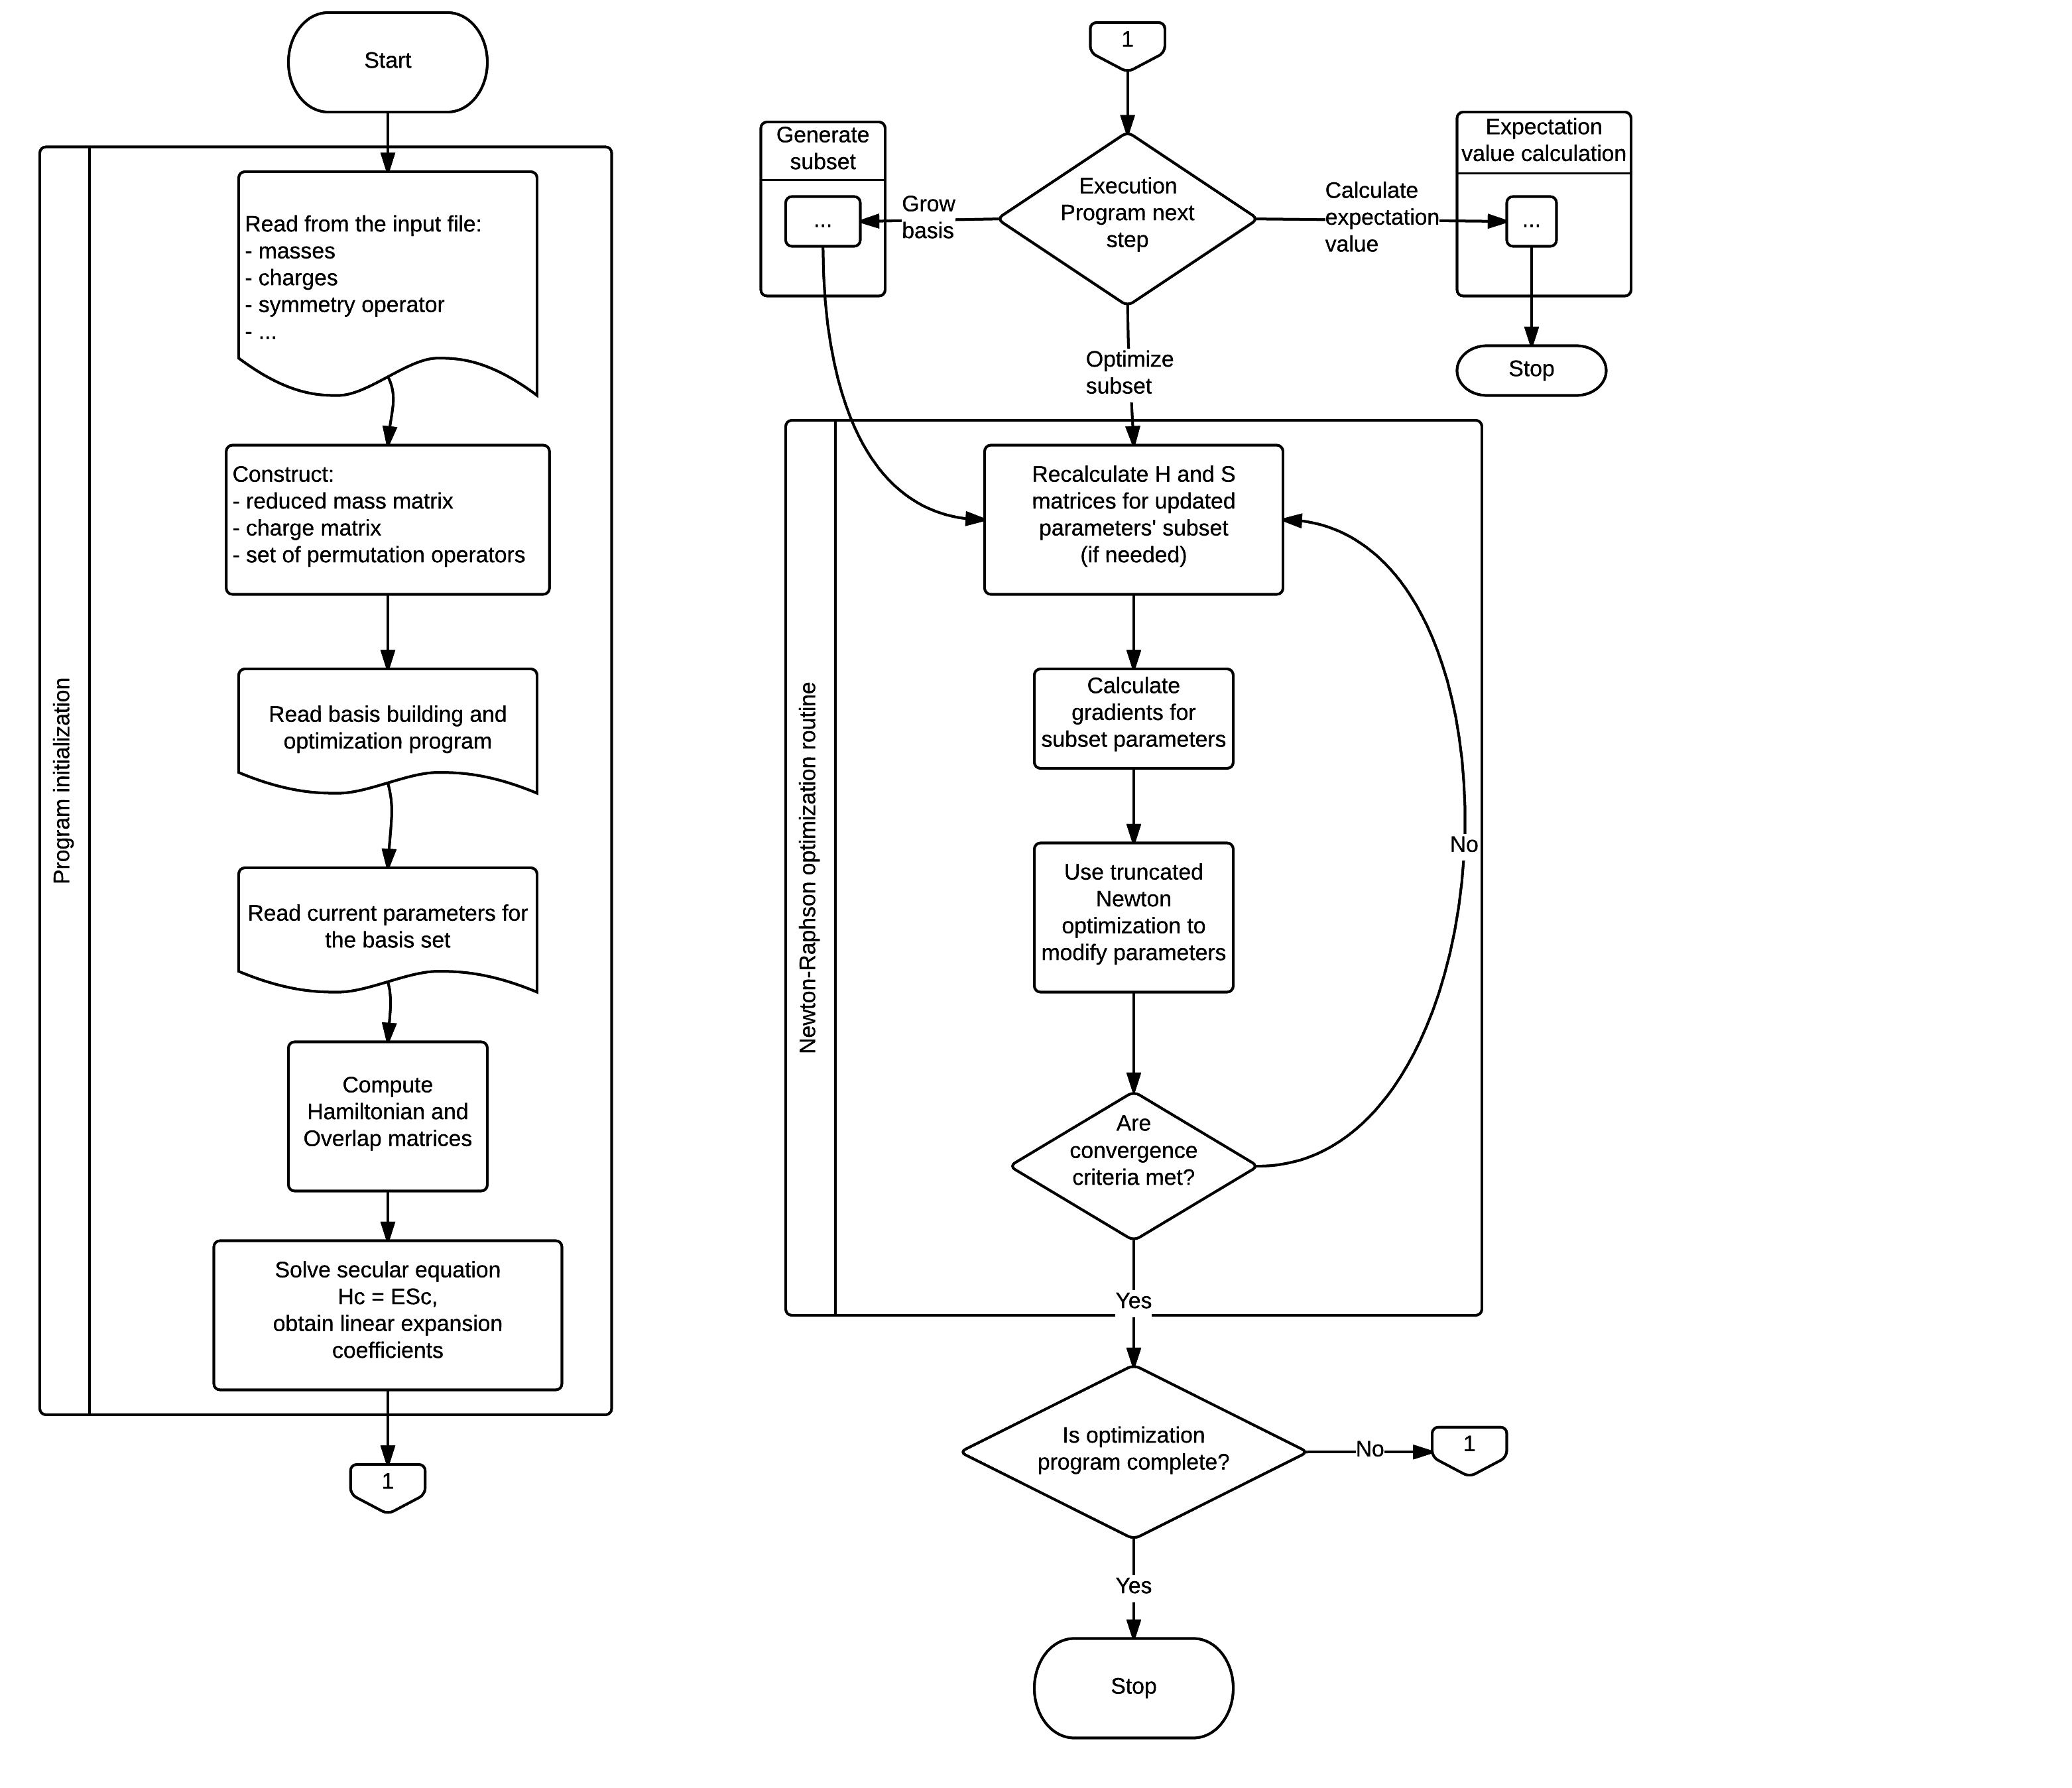

Source: Figure 3.1 - Code Flowchart, ADVANCES IN MODELING OF PHYSICAL SYSTEMS USING EXPLICITLY CORRELATED GAUSSIAN FUNCTIONS, by Nikita Kirnosov, https://repository.arizona.edu/bitstream/handle/10150/594645/azu_etd_14350_sip1_m.pdf?sequence=1&isAllowed=y

## References

- <a name="references"></a>**[Bubin2013]** S. Bubin, M. Pavanello, W.-C. Tung, K. L. Sharkey, L. Adamowicz, *Born–Oppenheimer and Non-Born–Oppenheimer, Atomic and Molecular Calculations with Explicitly Correlated Gaussians*, Chem. Rev. **113**, 36–79 (2013). [doi:10.1021/cr200419d](https://doi.org/10.1021/cr200419d)
- **[Sharkey2014]** K. L. Sharkey, L. Adamowicz, *An algorithm for nonrelativistic quantum-mechanical finite-nuclear-mass variational calculations of nitrogen atom in $L=0$, $M=0$ states…*, J. Chem. Phys. **140**, 174112 (2014). [doi:10.1063/1.4873916](https://doi.org/10.1063/1.4873916)
- **[Bubin2008]** S. Bubin, L. Adamowicz, *Energy and energy gradient matrix elements with $N$-particle explicitly correlated complex Gaussian basis functions with $L=1$*, J. Chem. Phys. **128**, 114107 (2008). [doi:10.1063/1.2894866](https://doi.org/10.1063/1.2894866)
- **[Kinghorn1996]** D. B. Kinghorn, *Integrals and Derivatives for Correlated Gaussian Functions Using Matrix Differential Calculus*, Int. J. Quantum Chem. **57**, 141–155 (1996).
- **[Hornyak2019]** I. Hornyák, L. Adamowicz, S. Bubin, *Ground and excited $^1S$ states of the beryllium atom*, Phys. Rev. A **100**, 032504 (2019).
- **[Bralin2019]** A. Bralin, S. Bubin et al., *The Rydberg series of the lithium atom: calculations with all-electron explicitly correlated Gaussian functions*, Chem. Phys. Lett. **730**, 497–502 (2019). [doi:10.1016/j.cplett.2019.06.051](https://doi.org/10.1016/j.cplett.2019.06.051)
- **[Seth2011]** P. Seth, P. L. Ríos, R. J. Needs, J. Chem. Phys. **134**, 084105 (2011).
- **[Pavanello2009]** M. Pavanello, L. Adamowicz, *High-accuracy calculations of the ground and excited states of $\mathrm{H_3^+}$*, J. Chem. Phys. **130**, 034104 (2009). [doi:10.1063/1.3058634](https://doi.org/10.1063/1.3058634)
- **[Lang2024]** L. Lang, H. M. Cezar, L. Adamowicz, T. B. Pedersen, *Quantum Definition of Molecular Structure*, J. Am. Chem. Soc. **146**(3), 1760–1764 (2024). [doi:10.1021/jacs.3c11467](https://doi.org/10.1021/jacs.3c11467)
- **[ATOMMOLnonBO]** S. Bubin, L. Adamowicz, *Computer program* `atom-mol-nonBO`…, J. Chem. Phys. **152**, 204102 (2020). [doi:10.1063/1.5144268](https://doi.org/10.1063/1.5144268) · [GitHub](https://github.com/sbubin/ATOM-MOL-nonBO)
- **[Revels2016]** J. Revels, M. Lubin, T. Papamarkou, *Forward-Mode Automatic Differentiation in Julia*, arXiv:1607.07892 (2016).
- **[Bezanson2017]** J. Bezanson, A. Edelman, S. Karpinski, V. B. Shah, *Julia: A Fresh Approach to Numerical Computing*, SIAM Rev. **59**(1), 65–98 (2017).
- **[HeliumAtom]** Reference $1{}^1S$ ground-state energy of helium (finite mass), as used in the `He` notebook.

In [2]:
# Display Julia version information
versioninfo()

Julia Version 1.12.6
Commit 15346901f00 (2026-04-09 19:20 UTC)
Build Info:
  Official https://julialang.org release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 22 × Intel(R) Core(TM) Ultra 9 185H
  WORD_SIZE: 64
  LLVM: libLLVM-18.1.7 (ORCJIT, alderlake)
  GC: Built with stock GC
Threads: 1 default, 1 interactive, 1 GC (on 22 virtual cores)
